<a href="https://colab.research.google.com/github/haroonahmaddata/Basic-to-Advance-NLP-Projects/blob/main/Q%26A_with_Transformer_%20Lv_03/Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Finetuning BERT-Large and Distil-BERT**
Overview of the project goal: fine-tuning two pre-trained models (BERT-Large and DistilBERT) for Question Answering on the SQuAD dataset.

Explains why two models are being used (comparison of performance vs efficiency).

In [ ]:
!pip install transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00


#**Importing Libraries**
Lists all Python packages used:

Transformers → models, tokenizers, pipelines, Trainer API.

Datasets → for loading SQuAD.

PyTorch → for GPU acceleration and model training.

Utilities like re, string, collections.Counter for evaluation metrics.

In [ ]:
from transformers import DefaultDataCollator
from collections import defaultdict, Counter
from datasets import load_dataset
import numpy as np
import torch, os
import re
import string
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,
    TrainingArguments,
    Trainer,
    default_data_collator,
    pipeline
)

#**Loading SQuAD Dataset**
Load the SQuAD v1/v2 dataset using datasets.load_dataset.

Split into train and test/validation sets.

Prepares raw data for tokenization.

In [ ]:
squad = load_dataset("squad", split="train[:5000]")
squad = squad.train_test_split(test_size=0.2)
squad["train"][0]

#**Loading Model and Tokenizer**
Loads pre-trained BERT-Large and DistilBERT models for QA.

Loads corresponding tokenizers.

These models will later be fine-tuned on SQuAD.

In [ ]:
from transformers import AutoModelForQuestionAnswering, TrainingArguments, Trainer

# Load BERT-Large for Question Answering
model = AutoModelForQuestionAnswering.from_pretrained("bert-large-uncased-whole-word-masking")


model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-large-uncased-whole-word-masking and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-large-uncased-whole-word-masking")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/434 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

#**Preprocessing Dataset**
Optional cleaning or formatting of the dataset (e.g., truncating contexts, handling missing answers, lowercase, etc.).

Ensures the dataset is in the correct structure for tokenization.

In [ ]:
def preprocess_function(examples):
    questions = [q.strip() for q in examples["question"]]
    inputs = tokenizer(
        questions,
        examples["context"],
        max_length=384,
        truncation="only_second",
        return_offsets_mapping=True,
        padding="max_length",
    )

    offset_mapping = inputs.pop("offset_mapping")
    answers = examples["answers"]
    start_positions = []
    end_positions = []

    for i, offset in enumerate(offset_mapping):
        answer = answers[i]
        start_char = answer["answer_start"][0]
        end_char = answer["answer_start"][0] + len(answer["text"][0])
        sequence_ids = inputs.sequence_ids(i)

        # Find the start and end of the context
        idx = 0
        while sequence_ids[idx] != 1:
            idx += 1
        context_start = idx
        while sequence_ids[idx] == 1:
            idx += 1
        context_end = idx - 1

        # If the answer is not fully inside the context, label it (0, 0)
        if offset[context_start][0] > end_char or offset[context_end][1] < start_char:
            start_positions.append(0)
            end_positions.append(0)
        else:
            # Otherwise it's the start and end token positions
            idx = context_start
            while idx <= context_end and offset[idx][0] <= start_char:
                idx += 1
            start_positions.append(idx - 1)

            idx = context_end
            while idx >= context_start and offset[idx][1] >= end_char:
                idx -= 1
            end_positions.append(idx + 1)

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions
    return inputs

#**Tokenization**
Converts text (context + question) into token IDs and attention masks.

Handles model-specific tokenization rules (like [CLS], [SEP] tokens).

Key for feeding text into transformers.

In [ ]:
tokenized_squad = squad.map(preprocess_function, batched=True, remove_columns=squad["train"].column_names)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

#**Defining Training Features**
Uses prepare_train_features function.

Splits long contexts into overlapping chunks (stride) to ensure answers aren’t truncated.

Maps start and end positions of answers to token indices.

Prepares the dataset for supervised training.

In [ ]:
#collect and organise information
data_collator = DefaultDataCollator(return_tensors="tf")

max_length = 384
doc_stride = 128

def prepare_train_features(examples):
    # Tokenize with overflow so long contexts are split into multiple features
    tokenized_examples = tokenizer(
        examples["question"],
        examples["context"],
        truncation="only_second",
        max_length=max_length,
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
        # use_fast=True already set when tokenizer created
    )

    # This maps feature -> original example index
    sample_mapping = tokenized_examples.pop("overflow_to_sample_mapping")
    offset_mapping = tokenized_examples.pop("offset_mapping")

    tokenized_examples["start_positions"] = []
    tokenized_examples["end_positions"] = []

    for feature_index, offsets in enumerate(offset_mapping):
        input_ids = tokenized_examples["input_ids"][feature_index]
        sequence_ids = tokenized_examples.sequence_ids(feature_index)

        # find CLS index for this feature (fallback label)
        try:
            cls_index = input_ids.index(tokenizer.cls_token_id)
        except ValueError:
            # fallback to 0 if cls token not found (very rare)
            cls_index = 0

        sample_index = sample_mapping[feature_index]
        answers = examples["answers"][sample_index]

        # If the example has no answers, set to CLS
        if len(answers["answer_start"]) == 0:
            tokenized_examples["start_positions"].append(cls_index)
            tokenized_examples["end_positions"].append(cls_index)
            continue

        # Only take first answer (SQuAD usually has one)
        start_char = answers["answer_start"][0]
        end_char = start_char + len(answers["text"][0])

        # find token index range for the context in this feature
        # token_start is first index where sequence_ids == 1
        token_start_index = 0
        while sequence_ids[token_start_index] != 1:
            token_start_index += 1
        token_end_index = len(sequence_ids) - 1
        while sequence_ids[token_end_index] != 1:
            token_end_index -= 1

        # If answer not fully inside this span, label as CLS
        if not (offsets[token_start_index][0] <= start_char and offsets[token_end_index][1] >= end_char):
            tokenized_examples["start_positions"].append(cls_index)
            tokenized_examples["end_positions"].append(cls_index)
        else:
            # Find token index that contains start_char
            idx = token_start_index
            while idx <= token_end_index and offsets[idx][0] <= start_char:
                idx += 1
            start_token = idx - 1

            # Find token index that contains end_char
            idx = token_end_index
            while idx >= token_start_index and offsets[idx][1] >= end_char:
                idx -= 1
            end_token = idx + 1

            tokenized_examples["start_positions"].append(start_token)
            tokenized_examples["end_positions"].append(end_token)

    return tokenized_examples


#**Prepare the valiation features**
Which token belongs to which original example (example_id)

The offsets of context tokens for mapping predictions back to the original text

Handling long contexts that are split into overlapping chunks.

In [ ]:
def prepare_validation_features(examples):
    tokenized_examples = tokenizer(
        examples["question"],
        examples["context"],
        truncation="only_second",
        max_length=max_length,
        stride=doc_stride,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    sample_mapping = tokenized_examples.pop("overflow_to_sample_mapping")

    tokenized_examples["example_id"] = []
    for i in range(len(tokenized_examples["input_ids"])):
        sample_index = sample_mapping[i]
        tokenized_examples["example_id"].append(examples["id"][sample_index])

        # Set offsets of question tokens to None, we only need offsets for the context
        sequence_ids = tokenized_examples.sequence_ids(i)
        tokenized_examples["offset_mapping"][i] = [
            off if sequence_ids[k] == 1 else None
            for k, off in enumerate(tokenized_examples["offset_mapping"][i])
        ]

    return tokenized_examples


#**Tokenizing the validation/test set**
Applies prepare_validation_features to the test split.

Removes original columns but keeps offsets for evaluation.

Sanity check prints the new columns to verify tokenization worked as expected.

In [ ]:
# map the tokenization over both splits
tokenized_squad = squad.map(
    prepare_train_features,
    batched=True,
    remove_columns=squad["train"].column_names  # uses same column names for mapping both splits
)

# build validation features (keeps offset_mapping & example_id for postprocessing)
tokenized_val = squad["test"].map(prepare_validation_features, batched=True, remove_columns=squad["test"].column_names)

# quick sanity
print("Tokenized columns (train):", tokenized_squad["train"].column_names)
print("Tokenized columns (test):", tokenized_val.column_names)


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenized columns (train): ['input_ids', 'token_type_ids', 'attention_mask', 'start_positions', 'end_positions']
Tokenized columns (test): ['input_ids', 'token_type_ids', 'attention_mask', 'offset_mapping', 'example_id']


In [ ]:
# prefer numpy arrays (prevents TF from ever seeing torch tensors)
tokenized_squad["train"].set_format(type="np")
tokenized_squad["test"].set_format(type="np")
tokenized_val.set_format(type="np")  # features for prediction

collator = default_data_collator


#**Training Args**
Sets up TrainingArguments for Hugging Face Trainer:

Learning rate, batch size, number of epochs.

Logging, checkpointing, mixed precision (fp16) if GPU available.

Controls training behavior and performance.

In [ ]:
# Full training args (reduce batch size if you hit OOM)
args_full = TrainingArguments(
    output_dir="my_awesome_qa_model",
    learning_rate=2e-5,
    per_device_train_batch_size=8,   # use 16 only if GPU has enough memory
    per_device_eval_batch_size=16,
    num_train_epochs=3, #3iterations
    weight_decay=0.01,
    logging_steps=200,
    save_strategy="epoch",
    fp16=torch.cuda.is_available(),
    report_to="none",
    push_to_hub=False,
)

# set eval/evaluation strategy compatibly
if hasattr(args_full, "eval_strategy"):
    args_full.eval_strategy = "epoch"
elif hasattr(args_full, "evaluation_strategy"):
    args_full.evaluation_strategy = "epoch"

# Ensure datasets still numpy
tokenized_squad["train"].set_format(type="np")
tokenized_squad["test"].set_format(type="np")

trainer_full = Trainer(
    model=model,
    args=args_full,
    train_dataset=tokenized_squad["train"],
    eval_dataset=tokenized_squad["test"],   # or tokenized_val if you prefer features
    tokenizer=tokenizer,
    data_collator=collator
)

trainer_full.train()


/tmp/ipython-input-2791077602.py:26: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_full = Trainer(


Epoch,Training Loss,Validation Loss
1,2.207700,1.690842
2,1.332500,1.472940
3,1.013800,1.503287


TrainOutput(global_step=1533, training_loss=1.6370181825840622, metrics={'train_runtime': 162.4511, 'train_samples_per_second': 75.438, 'train_steps_per_second': 9.437, 'total_flos': 1200865305669120.0, 'train_loss': 1.6370181825840622, 'epoch': 3.0})

In [ ]:
# --- Define model checkpoints ---
bert_large_ckpt = "./my_awesome_qa_model/checkpoint-1530"
distil_bert_ckpt = "./my_awesome_qa_model/checkpoint-1533"

#**Q&A Tests**
Example inference runs:

User provides questions (with or without context).

BERT-Large and DistilBERT generate answers.

Allows quick qualitative assessment.

#**Evaluation Metrics**
Defines metrics for model performance:

Exact Match (EM) → percentage of answers that match exactly.

F1 Score → token-level overlap between predicted and true answers.

Can use custom functions or Hugging Face evaluate library.

In [ ]:
# --- Load Test Dataset ---
squad_test = load_dataset("squad", split="train[:5000]").train_test_split(test_size=0.2)["test"]

# --- Normalization & metric functions ---
def normalize_answer(s):
    """Lower text and remove punctuation, articles, and extra whitespace."""
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)
    def white_space_fix(text):
        return ' '.join(text.split())
    def remove_punc(text):
        return ''.join(ch for ch in text if ch not in set(string.punctuation))
    def lower(text):
        return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def compute_exact(a_pred, a_true):
    return int(normalize_answer(a_pred) == normalize_answer(a_true))

def compute_f1(a_pred, a_true):
    pred_tokens = normalize_answer(a_pred).split()
    true_tokens = normalize_answer(a_true).split()
    common = Counter(pred_tokens) & Counter(true_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0
    precision = num_same / len(pred_tokens)
    recall = num_same / len(true_tokens)
    return 2 * precision * recall / (precision + recall)

# --- Define model checkpoints ---
bert_large_ckpt = "./my_awesome_qa_model/checkpoint-1530"
distil_bert_ckpt = "./my_awesome_qa_model/checkpoint-1533"

# --- Load QA pipelines ---
bert_large_pipe = pipeline("question-answering", model=bert_large_ckpt, tokenizer=bert_large_ckpt, device=0)
distil_bert_pipe = pipeline("question-answering", model=distil_bert_ckpt, tokenizer=distil_bert_ckpt, device=0)

# --- Choose test set ---
squad_test = tokenized_squad["test"]

# --- Evaluation function ---
def evaluate_pipeline(qa_pipeline, test_set):
    exact_scores = []
    f1_scores = []

    for example in test_set:
        context = example["context"]
        question = example["question"]
        true_answer = example["answers"]["text"][0]

        pred = qa_pipeline({"context": context, "question": question})
        pred_answer = pred["answer"]

        exact_scores.append(compute_exact(pred_answer, true_answer))
        f1_scores.append(compute_f1(pred_answer, true_answer))

    em = 100.0 * sum(exact_scores) / len(exact_scores)
    f1 = 100.0 * sum(f1_scores) / len(f1_scores)
    return em, f1

# --- Run evaluations ---
# Use the original SQuAD test split
squad_test_raw = load_dataset("squad", split="train[:5000]").train_test_split(test_size=0.2)["test"]

# Now evaluate
em_bert, f1_bert = evaluate_pipeline(bert_large_pipe, squad_test_raw)
em_distil, f1_distil = evaluate_pipeline(distil_bert_pipe, squad_test_raw)

print(f"BERT-large -> Exact Match (EM): {em_bert:.2f}%, F1 Score: {f1_bert:.2f}%")
print(f"DistilBERT -> Exact Match (EM): {em_distil:.2f}%, F1 Score: {f1_distil:.2f}%")


Device set to use cuda:0
Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/question_answering.py:395: FutureWarning: Passing a list of SQuAD examples to the pipeline is deprecated and will be removed in v5. Inputs should be passed using the `question` and `context` keyword arguments instead.
  warnings.warn(


BERT-large -> Exact Match (EM): 74.40%, F1 Score: 85.20%
DistilBERT -> Exact Match (EM): 73.60%, F1 Score: 83.82%


In [ ]:
squad_test_orig = squad["test"]
for example in squad_test_orig.select(range(20)):
    context = example["context"]
    question = example["question"]
    true_answer = example["answers"]["text"][0]

    pred_bert = bert_large_pipe({"context": context, "question": question})["answer"]
    pred_distil = distil_bert_pipe({"context": context, "question": question})["answer"]

    print(f"Q: {question}")
    print(f"True: {true_answer}")
    print(f"BERT-large: {pred_bert}")
    print(f"DistilBERT: {pred_distil}")
    print("-"*50)


Q: Beyonce's sex appeal is characterized as what?
True: wide-ranging
BERT-large: wide-ranging
DistilBERT: wide-ranging
--------------------------------------------------
Q: Who in Chopin's family died shortly before they moved in 1827?
True: sister Emilia
BERT-large: sister Emilia
DistilBERT: Emilia
--------------------------------------------------
Q: How much cash did Beyonce put into the venture, the Survivor Foundation at startup?
True: 250,000
BERT-large: $250,000
DistilBERT: $250,000
--------------------------------------------------
Q: What establishment today contains what was known as the Warsaw Lyceum during that time?
True: Warsaw University
BERT-large: rectorate of Warsaw University
DistilBERT: Kazimierz Palace
--------------------------------------------------
Q: After her second solo album, what other entertainment venture did Beyonce explore?
True: acting
BERT-large: acting
DistilBERT: B'Day
--------------------------------------------------
Q: Who became the second Karm

#**Visualization**

EM/F1 comparison between models.

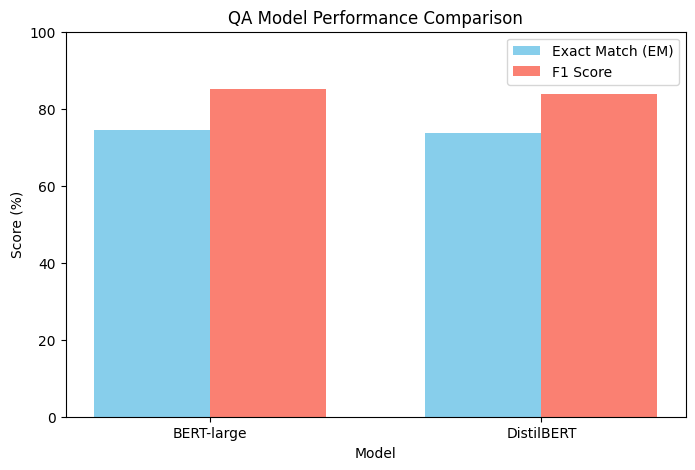